<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part IV · Preparing Data &nbsp;|&nbsp; Chapter 23</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Combining &amp; Reshaping Data <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five hands-on demos: merge two tables (and watch a join explode), stack files with concat, reshape wide to long and back, parse and resample dates, and split and extract from text.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | Joining tables | merge on a key: inner vs left, and where NaN appears |
| 2 | The fan-out trap | duplicate keys multiply rows; validate catches it |
| 3 | Wide and long | melt to long, pivot_table back to a summary grid |
| 4 | Parsing dates | to_datetime, .dt features, and resample a time series |
| 5 | Cleaning text | split and extract with the .str accessor |

> Note: this notebook uses current pandas (3.x) names: resample("ME") not "M", and regex=True for pattern replaces.

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(23)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12.5,"axes.titleweight":"bold","axes.titlecolor":INK,"legend.frameon":False})
print("✅ Environment ready. pandas", pd.__version__)

✅ Environment ready. pandas 3.0.3


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · JOINING TABLES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔗 merge on a key: inner vs left</div>
<div style="color:#4a5578;margin-top:6px">A merge matches rows on a shared key, the pandas version of a SQL JOIN. The how= argument decides which rows survive: inner (only matches, the default) can silently DROP rows, while left keeps every left row and fills the rest with NaN.</div>
</div>

In [2]:
customers = pd.DataFrame({"cust_id":[1,2,3], "name":["Ana","Ben","Cy"]})
orders    = pd.DataFrame({"cust_id":[1,1,2,99], "amount":[50,30,80,20]})   # cust 99 has no customer; cust 3 has no order

inner = orders.merge(customers, on="cust_id", how="inner")
left  = orders.merge(customers, on="cust_id", how="left", indicator=True)
print(f"orders rows: {len(orders)}")
print(f"inner join : {len(inner)} rows  (order 99 dropped, no matching customer)")
print(f"left join  : {len(left)} rows  (order 99 kept, name = NaN)\n")
print(left)
print("\nindicator shows where each row matched: both vs left_only.")

orders rows: 4
inner join : 3 rows  (order 99 dropped, no matching customer)
left join  : 4 rows  (order 99 kept, name = NaN)

   cust_id  amount name     _merge
0        1      50  Ana       both
1        1      30  Ana       both
2        2      80  Ben       both
3       99      20  NaN  left_only

indicator shows where each row matched: both vs left_only.


<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · THE FAN-OUT TRAP</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">💥 Duplicate keys multiply rows</div>
<div style="color:#4a5578;margin-top:6px">The quietest bug in data work: when a key is duplicated on BOTH sides, a merge produces every combination within that key, multiplying rows and inflating any sum you compute next. The validate= argument asserts the relationship and raises if it is violated.</div>
</div>

In [3]:
left_t  = pd.DataFrame({"key":[1,1], "L":["a","b"]})    # key 1 twice
right_t = pd.DataFrame({"key":[1,1], "R":["x","y"]})    # key 1 twice

fan = left_t.merge(right_t, on="key")
print(f"2 rows x 2 rows on the same key -> {len(fan)} rows (a many-to-many fan-out):")
print(fan)

print("\nGuard every important merge with validate=:")
try:
    left_t.merge(right_t, on="key", validate="one_to_one")
except Exception as e:
    print(f"  validate='one_to_one' raised {type(e).__name__}: {str(e)[:60]}...")

2 rows x 2 rows on the same key -> 4 rows (a many-to-many fan-out):
   key  L  R
0    1  a  x
1    1  a  y
2    1  b  x
3    1  b  y

Guard every important merge with validate=:
  validate='one_to_one' raised MergeError: Merge keys are not unique in either left or right dataset; n...


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · WIDE AND LONG</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔄 melt to long, pivot_table back</div>
<div style="color:#4a5578;margin-top:6px">Tidy/long format (one row per observation) is what plots and models want; wide format (years spread across columns) is what reports want. melt unpivots wide to long; pivot_table aggregates long back to a wide summary, and unlike plain pivot it survives duplicate combinations.</div>
</div>

In [4]:
wide = pd.DataFrame({"region":["North","South"], "2021":[120,90], "2022":[135,110], "2023":[150,95]})
print("WIDE (years are columns):"); print(wide)

long = wide.melt(id_vars="region", var_name="year", value_name="sales")
print("\nLONG / tidy (each row is one region-year):"); print(long)

# pivot_table back to a grid, with totals
grid = long.pivot_table(index="region", columns="year", values="sales", aggfunc="sum", margins=True)
print("\nback to a WIDE summary with margins=True (totals):"); print(grid)

WIDE (years are columns):
  region  2021  2022  2023
0  North   120   135   150
1  South    90   110    95

LONG / tidy (each row is one region-year):
  region  year  sales
0  North  2021    120
1  South  2021     90
2  North  2022    135
3  South  2022    110
4  North  2023    150
5  South  2023     95

back to a WIDE summary with margins=True (totals):
year    2021  2022  2023  All
region                       
North    120   135   150  405
South     90   110    95  295
All      210   245   245  700


<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · PARSING DATES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📅 to_datetime, .dt, and resample</div>
<div style="color:#4a5578;margin-top:6px">Real datetimes (not strings) sort correctly, do arithmetic, and filter by range. to_datetime parses mixed formats; the .dt accessor extracts features (year, month, day name); and resample rebins a time series, the time-series version of groupby.</div>
</div>

parsed dates (bad one -> NaT):
[Timestamp('2021-03-01 00:00:00'), Timestamp('2021-03-04 00:00:00'), Timestamp('2021-05-12 00:00:00'), NaT, Timestamp('2021-08-15 00:00:00')]

.dt features: year=[2021.0, 2021.0, 2021.0, nan, 2021.0]
day names   : ['Monday', 'Thursday', 'Wednesday', nan, 'Sunday']

120 daily values -> 4 monthly totals via resample('ME')


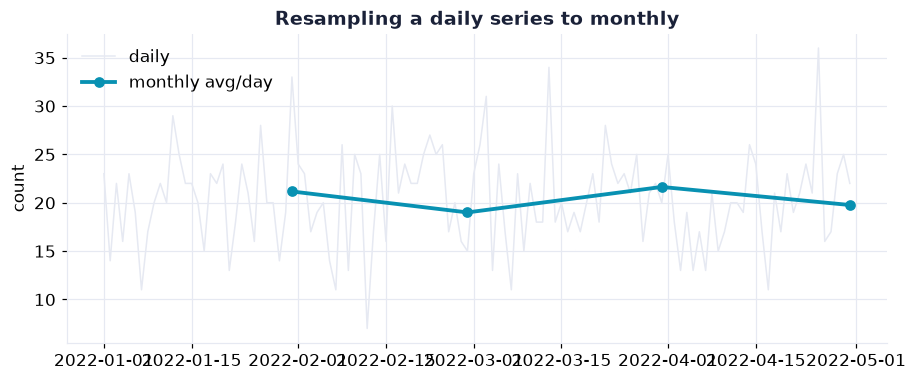

In [5]:
raw = pd.Series(["2021-03-01","03/04/2021","2021/05/12","not a date","2021-08-15"])
dates = pd.to_datetime(raw, errors="coerce", format="mixed")
print("parsed dates (bad one -> NaT):"); print(dates.tolist())
print(f"\n.dt features: year={dates.dt.year.tolist()}")
print(f"day names   : {dates.dt.day_name().tolist()}")

# a daily series -> monthly totals via resample
idx = pd.date_range("2022-01-01", periods=120, freq="D")     # "D" daily
daily = pd.Series(rng.poisson(20, 120), index=idx)
monthly = daily.resample("ME").sum()                          # "ME" = month end (pandas 3.x name)
print(f"\n120 daily values -> {len(monthly)} monthly totals via resample('ME')")

fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.plot(daily.index, daily.values, color=GRID, lw=1, label="daily")
ax.plot(monthly.index, monthly.values/30, color=CYAN, lw=2.5, marker="o", label="monthly avg/day")
ax.set_title("Resampling a daily series to monthly"); ax.set_ylabel("count"); ax.legend()
plt.tight_layout(); plt.show()

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · CLEANING TEXT</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🧵 split and extract with .str</div>
<div style="color:#4a5578;margin-top:6px">The .str accessor runs string operations across a whole column at once. Split a combined field into separate columns, pull a number out with a small regex, and standardize casing and whitespace (Chapter 19). Note: in modern pandas, .str.replace needs regex=True for patterns.</div>
</div>

In [6]:
df = pd.DataFrame({"place":["Austin, TX","Reno, NV","  Miami, FL "], "weight":["12.5 kg","3 kg","40.2 kg"]})

# split "City, State" into two clean columns
df[["city","state"]] = df["place"].str.strip().str.split(",", expand=True)
df["city"] = df["city"].str.strip(); df["state"] = df["state"].str.strip()

# extract the numeric weight with a regex capture group
df["kg"] = df["weight"].str.extract(r"(\d+\.?\d*)").astype(float)

# strip non-digits from a code (regex=True is required for a pattern)
codes = pd.Series(["ID-0042","ID 0043","id_0044"])
clean_codes = codes.str.replace(r"\D", "", regex=True).str.zfill(6)

print(df[["city","state","kg"]])
print("\ncleaned codes:", clean_codes.tolist())

     city state    kg
0  Austin    TX  12.5
1    Reno    NV   3.0
2   Miami    FL  40.2

cleaned codes: ['000042', '000043', '000044']


## 🏪 Real-World Example: Reshaping Store Sales
Store sales in **long** (tidy) format, 48 rows of one-per-store-month. We **pivot** it to a compact 4-by-12 report a human can read, **melt** it back to the tidy shape a model wants (a clean round-trip), and then **merge** it with a small store-to-region lookup to roll the numbers up by region. Reshape and combine, the two everyday moves.

long shape (48, 3)  ->  pivot to WIDE (4, 12)  ->  melt back to LONG (48, 3)

regional totals after the merge: {'East': 8569, 'West': 9276}


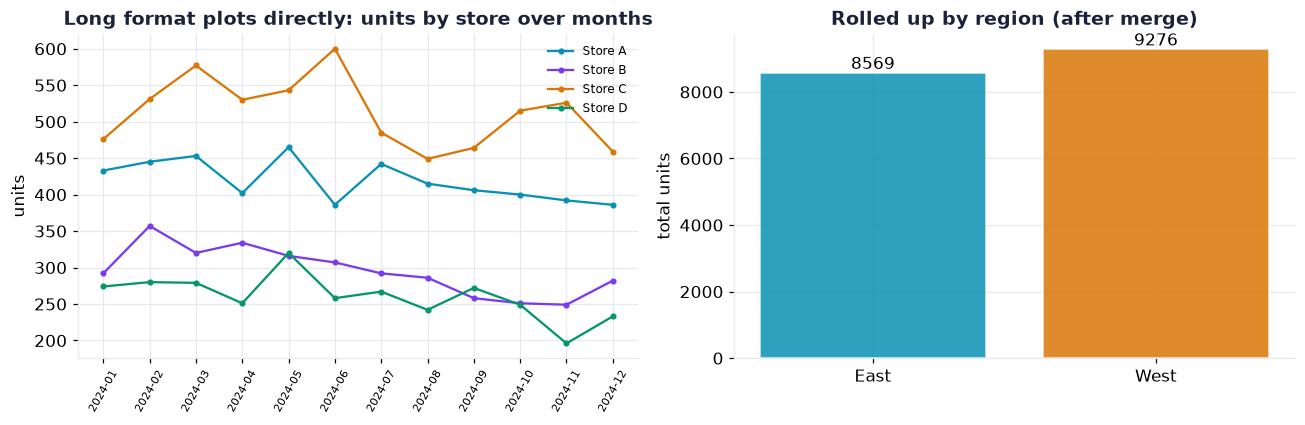

In [7]:
# --- Real-World beat: pivot / melt round-trip, then a merge ---
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    long = pd.read_excel("../../data/combining-and-reshaping-data--store_sales_long.xlsx", sheet_name="Data")
except FileNotFoundError: long = pd.read_excel(BASE+"combining-and-reshaping-data--store_sales_long.xlsx", sheet_name="Data")
wide = long.pivot(index="store", columns="month", values="units_sold")
back = wide.reset_index().melt(id_vars="store", var_name="month", value_name="units_sold")
print(f"long shape {long.shape}  ->  pivot to WIDE {wide.shape}  ->  melt back to LONG {back.shape}")
lookup = pd.DataFrame({"store": ["Store A","Store B","Store C","Store D"], "region": ["East","East","West","West"]})
merged = long.merge(lookup, on="store", validate="many_to_one")
region_tot = merged.groupby("region").units_sold.sum()
print("\nregional totals after the merge:", region_tot.to_dict())
fig, ax = plt.subplots(1, 2, figsize=(12,4))
for st, c in zip(sorted(long.store.unique()), [CYAN, PURPLE, AMBER, GREEN]):
    s = long[long.store==st]; ax[0].plot(s.month, s.units_sold, marker="o", ms=3, color=c, label=st)
ax[0].set_title("Long format plots directly: units by store over months")
ax[0].tick_params(axis="x", rotation=60, labelsize=7); ax[0].set_ylabel("units"); ax[0].legend(fontsize=8)
ax[1].bar(region_tot.index, region_tot.values, color=[CYAN, AMBER], alpha=0.85, edgecolor="white")
ax[1].bar_label(ax[1].containers[0], fmt="%d"); ax[1].set_title("Rolled up by region (after merge)"); ax[1].set_ylabel("total units")
plt.tight_layout(); plt.show()

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>merge</b> joins on a key; <b>how=</b> picks which rows survive (inner drops, left keeps all left rows).</li>
<li>Duplicate keys cause a <b>fan-out</b> that multiplies rows; guard merges with <b>validate=</b>.</li>
<li><b>melt</b> reshapes wide to long (for plots/models); <b>pivot_table</b> aggregates long to a wide summary.</li>
<li><b>to_datetime</b> + the <b>.dt</b> accessor unlock sorting, features, and <b>resample</b> on time series.</li>
<li>The <b>.str</b> accessor cleans text in bulk: split, extract, strip, lower; pass regex=True for patterns.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>